## 0. Pre-processamento

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.stats import f_oneway
from scipy.stats import chi2_contingency
import numpy as np

#imports 2026
import plotly.express as px
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import adjusted_rand_score



In [2]:
dados = pd.read_csv("https://raw.githubusercontent.com/HammadN98/Agrupamento-de-clientes/refs/heads/main/dados/E-commerce_CustomerBehavior.csv")
dados

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied
...,...,...,...,...,...,...,...,...,...,...,...
345,446,Male,32,Miami,Silver,660.30,10,3.8,True,42,Unsatisfied
346,447,Female,36,Houston,Bronze,470.50,8,3.0,False,27,Neutral
347,448,Female,30,New York,Gold,1190.80,16,4.5,True,28,Satisfied
348,449,Male,34,Los Angeles,Silver,780.20,11,4.2,False,21,Neutral


## 1. Conhecendo os dados

In [3]:
dados.head()

,Customer ID,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,101,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,102,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,103,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied
3,104,Male,30,San Francisco,Gold,1480.30,19,4.7,False,12,Satisfied
4,105,Male,27,Miami,Silver,720.40,13,4.0,True,55,Unsatisfied


In [4]:
dados.describe()

,Customer ID,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
count,350.000000,350.000000,350.000000,350.000000,350.000000,350.000000
mean,275.500000,33.597143,845.381714,12.600000,4.019143,26.588571
std,101.180532,4.870882,362.058695,4.155984,0.580539,13.440813
min,101.000000,26.000000,410.800000,7.000000,3.000000,9.000000
25%,188.250000,30.000000,502.000000,9.000000,3.500000,15.000000
50%,275.500000,32.500000,775.200000,12.000000,4.100000,23.000000
75%,362.750000,37.000000,1160.600000,15.000000,4.500000,38.000000
max,450.000000,43.000000,1520.100000,21.000000,4.900000,63.000000


In [5]:
# 1. Distribuição da Idade
fig = px.histogram(
    dados, x='Age', nbins=30,
    title='Distribuição da Idade dos Clientes',
    marginal='box',
    color_discrete_sequence=['#636EFA'],
    opacity=0.85
)
fig.update_layout(
    bargap=0.08,
    xaxis_title='Idade',
    yaxis_title='Frequência',
    title_font_size=18,
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#E5E5E5'),
    yaxis=dict(showgrid=True, gridcolor='#E5E5E5'),
)
fig.show()

# 2. Distribuição do Gasto Total
fig = px.histogram(
    dados, x='Total Spend', nbins=30,
    title='Distribuição do Gasto Total (R$)',
    marginal='box',
    color_discrete_sequence=['#EF553B'],
    opacity=0.85
)
fig.update_layout(
    bargap=0.08,
    xaxis_title='Gasto Total',
    yaxis_title='Frequência',
    title_font_size=18,
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#E5E5E5'),
    yaxis=dict(showgrid=True, gridcolor='#E5E5E5'),
)
fig.show()

# 3. Dias Desde a Última Compra
fig = px.histogram(
    dados, x='Days Since Last Purchase', nbins=30,
    title='Distribuição de Dias Desde a Última Compra',
    marginal='box',
    color_discrete_sequence=['#00CC96'],
    opacity=0.85
)
fig.update_layout(
    bargap=0.08,
    xaxis_title='Dias Desde a Última Compra',
    yaxis_title='Frequência',
    title_font_size=18,
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(showgrid=True, gridcolor='#E5E5E5'),
    yaxis=dict(showgrid=True, gridcolor='#E5E5E5'),
)
fig.show()

###Interpretação

**Distribuição de Idade:** A base é bem concentrada — 80% dos clientes têm entre 26 e 37 anos, com média em torno de 33. Não tem aquela cauda longa de clientes mais velhos, o que sugere um público bem definido. Pouco espaço pra variação aqui, o que é útil pra segmentação: a idade por si só não vai separar muito os grupos.

**Gasto Total:** Distribuição com leve assimetria à direita (skew ~0.56), o que indica que existe uma parcela menor de clientes com gastos bem altos puxando a média pra cima. A mediana fica em torno de R$775, enquanto a média vai pra R$845 — essa diferença já conta onde estão os clientes de alto valor. O boxplot confirma: sem outliers extremos, mas o Q3 em ~R$1160 mostra que tem um grupo considerável que gasta bastante.

**Dias Desde a Última Compra:** Comportamento parecido com o gasto — assimetria positiva, mediana em ~23 dias, mas com uma cauda chegando em 63 dias. Praticamente metade da base comprou nos últimos 23 dias, mas tem um grupo relevante que está sumido há mais tempo. Esse grupo dos "mais de 38 dias" (Q3) é candidato a campanhas de reativação.

In [6]:
# 4. Gasto Total por Tipo de Assinatura
fig = px.box(
    dados, x='Membership Type', y='Total Spend',
    color='Membership Type',
    title='Gasto Total por Tipo de Assinatura',
    color_discrete_map={
        'Bronze': '#CD7F32',
        'Silver': '#A8A9AD',
        'Gold':   '#FFD700'
    },
    points='outliers',
    category_orders={'Membership Type': ['Bronze', 'Silver', 'Gold']}
)
fig.update_layout(
    xaxis_title='Tipo de Assinatura',
    yaxis_title='Gasto Total',
    title_font_size=18,
    plot_bgcolor='white',
    paper_bgcolor='white',
    yaxis=dict(showgrid=True, gridcolor='#E5E5E5'),
    showlegend=False
)
fig.show()

# 5. Gasto Total por Nível de Satisfação
fig = px.box(
    dados, x='Satisfaction Level', y='Total Spend',
    color='Satisfaction Level',
    title='Gasto Total por Nível de Satisfação',
    color_discrete_map={
        'Unsatisfied': '#EF553B',
        'Neutral':     '#FFA15A',
        'Satisfied':   '#00CC96'
    },
    points='outliers',
    category_orders={'Satisfaction Level': ['Unsatisfied', 'Neutral', 'Satisfied']}
)
fig.update_layout(
    xaxis_title='Nível de Satisfação',
    yaxis_title='Gasto Total',
    title_font_size=18,
    plot_bgcolor='white',
    paper_bgcolor='white',
    yaxis=dict(showgrid=True, gridcolor='#E5E5E5'),
    showlegend=False
)
fig.show()

# 6. Itens Comprados por Gênero
fig = px.box(
    dados, x='Gender', y='Items Purchased',
    color='Gender',
    title='Quantidade de Itens Comprados por Gênero',
    color_discrete_map={
        'Male':   '#636EFA',
        'Female': '#EF553B'
    },
    points='outliers'
)
fig.update_layout(
    xaxis_title='Gênero',
    yaxis_title='Itens Comprados',
    title_font_size=18,
    plot_bgcolor='white',
    paper_bgcolor='white',
    yaxis=dict(showgrid=True, gridcolor='#E5E5E5'),
    showlegend=False
)
fig.show()

###Interpretação

**Gasto por Membership:** A separação entre os níveis é muito clara e praticamente sem sobreposição — Bronze mediana ~R$475, Silver ~R$770, Gold ~R$1210. A variância de cada grupo é baixíssima (Bronze std de R$31, Silver R$60), o que indica que o tipo de assinatura é quase determinístico pro gasto. Na prática: o nível de membership é um proxy muito forte do valor do cliente. Interessante pra estratégia de upsell de plano.

**Gasto por Satisfação:** Aqui tem um padrão que chama atenção — clientes Satisfied gastam em média ~R$1280, enquanto Neutral e Unsatisfied ficam próximos entre si (~R$616 e ~R$595). Parece contra-intuitivo que Neutral e Unsatisfied tenham gastos parecidos, mas faz sentido: ambos tendem a ser Bronze/Silver. O takeaway de negócio é que **satisfação e gasto andam juntos**, ou seja, clientes que mais consomem também estão mais satisfeitos — o que pode indicar que a experiência de compra é boa, mas só pros clientes que já estão engajados.

**Itens por Gênero:** Diferença bem nítida — homens compram em média ~14 itens, mulheres ~10. As distribuições são razoavelmente compactas e sem muita sobreposição. Isso pode ser comportamental ou pode refletir o tipo de produto que cada grupo busca. Vale cruzar com as categorias de produto se estiverem disponíveis, porque essa diferença de ~4 itens por pedido tem impacto direto no ticket médio.

In [7]:
# 7. Heatmap de Correlação
import plotly.express as px

colunas_correlacao = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']

matriz_corr = dados[colunas_correlacao].corr().round(2)

fig = px.imshow(
    matriz_corr,
    text_auto=True,
    color_continuous_scale='RdBu_r',
    zmin=-1, zmax=1,
    title='Heatmap de Correlação entre Variáveis Numéricas',
    aspect='auto'
)
fig.update_layout(
    title_font_size=18,
    coloraxis_colorbar=dict(
        title='Correlação',
        tickvals=[-1, -0.5, 0, 0.5, 1],
        ticktext=['-1  (negativa forte)', '-0.5', '0', '0.5', '1  (positiva forte)']
    ),
    font=dict(size=13),
    plot_bgcolor='white',
    paper_bgcolor='white',
)
fig.update_traces(textfont_size=14)
fig.show()

###Interpretação

O heatmap revela um padrão forte e bem coerente:

**Trio altamente correlacionado:** Total Spend, Items Purchased e Average Rating têm correlações entre si de 0.92 a 0.97 — quase que multivariadas. Ou seja, quem gasta mais, compra mais itens *e* avalia melhor. Isso indica que não é só volume: a experiência de quem compra bastante é genuinamente melhor (ou quem está satisfeito compra mais, dependendo da direção da causalidade).

**Idade como fator inverso:** A idade tem correlação negativa moderada-forte com os três indicadores acima (-0.68, -0.69, -0.72). Clientes mais novos gastam mais, compram mais e avaliam melhor. Vale atenção aqui: pode ser um efeito de seleção (clientes mais novos são o público-alvo da plataforma e já chegam mais engajados) ou um padrão real de comportamento de compra por geração.

**Dias desde a última compra:** Correlação negativa com gasto (-0.54) e com os demais. Faz todo sentido — quem compra com mais frequência naturalmente gasta mais no total. A correlação com idade (0.17) é fraca, o que sugere que recência de compra não depende muito da faixa etária.

> **Para o modelo de clustering:** esse nível de correlação entre Total Spend, Items Purchased e Average Rating é um sinal de atenção. As três variáveis carregam informação muito parecida — incluir todas pode inflar o peso desse eixo no clustering. Vale monitorar se o PCA consegue separar bem as componentes.

## 2. Limpeza dos dados

In [8]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350 entries, 0 to 349
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Customer ID               350 non-null    int64  
 1   Gender                    350 non-null    object 
 2   Age                       350 non-null    int64  
 3   City                      350 non-null    object 
 4   Membership Type           350 non-null    object 
 5   Total Spend               350 non-null    float64
 6   Items Purchased           350 non-null    int64  
 7   Average Rating            350 non-null    float64
 8   Discount Applied          350 non-null    bool   
 9   Days Since Last Purchase  350 non-null    int64  
 10  Satisfaction Level        348 non-null    object 
dtypes: bool(1), float64(2), int64(4), object(4)
memory usage: 27.8+ KB


In [9]:
dados = dados.drop(columns='Customer ID')
dados_backup = dados
dados_reserva = dados


### 2.1 Removendo valores nulos

A categoria 'Satisfaction Level' e a unica que possui valore nulos

In [10]:
dados['Satisfaction Level'].unique()

array(['Satisfied', 'Neutral', 'Unsatisfied', nan], dtype=object)

In [11]:
dados = dados.dropna(subset=['Satisfaction Level'])
dados.shape

(348, 10)

### 2.2 VErificando a existencia de duplicatas

In [12]:
dados.duplicated().sum()

np.int64(180)

nada duplicado

### 2.3 Analisando outiliers

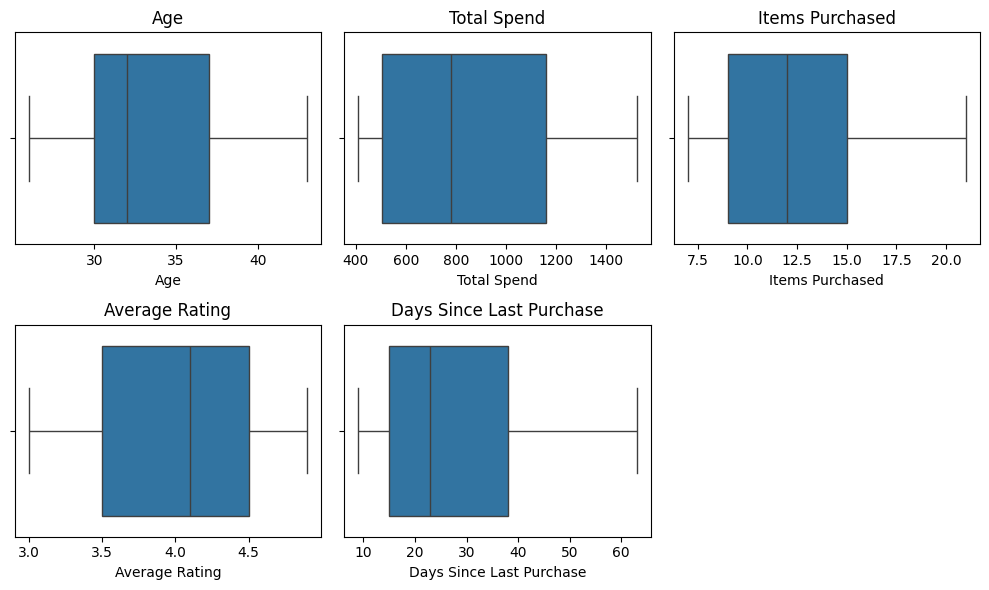

In [13]:
num_columns = dados.select_dtypes(include=['float64', 'int']).columns

plt.figure(figsize=(10, 6))
for i, col in enumerate(num_columns, 1):
    plt.subplot(2, (len(num_columns) + 1) // 2, i)
    sns.boxplot(x=dados[col])
    plt.title(col)
plt.tight_layout()
plt.show()


Outliers nao encontrados visualmente

## 3. Padronizacao das variaveis numericas

In [14]:
scaler = StandardScaler()


#num_columns = colunas numericas
dados[num_columns] = scaler.fit_transform(dados[num_columns])

dados_numericos_normalizados = dados[num_columns]
dados_numericos_normalizados

/tmp/ipykernel_18234/1051725957.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
0,-0.939761,0.754230,0.330381,0.996757,-0.120022
1,0.086720,-0.186319,-0.394236,0.132172,-0.640260
2,1.934386,-0.933192,-0.877314,-1.078247,1.143413
3,-0.734465,1.751261,1.538076,1.169674,-1.086179
4,-1.350354,-0.352721,0.088842,-0.040745,2.109570
...,...,...,...,...,...
345,-0.323873,-0.519124,-0.635775,-0.386579,1.143413
346,0.497312,-1.044635,-1.118853,-1.769915,0.028617
347,-0.734465,0.949704,0.813459,0.823840,0.102937
348,0.086720,-0.187149,-0.394236,0.305089,-0.417301


## 4. K-measn apenas com as variveis numericas originais apos a normalizacao

### 4.1 Numero de K usando o metodo do cotovelo

In [15]:
# 8. Método do Cotovelo
range_n_clusters = range(1, 11)
inertia = []

for k in range_n_clusters:
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    kmeans.fit(dados[num_columns])
    inertia.append(kmeans.inertia_)

elbow_df = pd.DataFrame({
    'Número de Clusters (K)': list(range_n_clusters),
    'Inércia': inertia
})

fig = px.line(
    elbow_df,
    x='Número de Clusters (K)',
    y='Inércia',
    title='Método do Cotovelo — Escolha do K Ideal',
    markers=True,
    color_discrete_sequence=['#636EFA']
)

# Destaque visual no ponto K=4 (cotovelo identificado)
fig.add_scatter(
    x=[4], y=[elbow_df.loc[elbow_df['Número de Clusters (K)'] == 4, 'Inércia'].values[0]],
    mode='markers+text',
    marker=dict(color='#EF553B', size=14, symbol='circle'),
    text=['  K = 4 (cotovelo)'],
    textposition='middle right',
    textfont=dict(color='#EF553B', size=13),
    showlegend=False
)

fig.update_layout(
    title_font_size=18,
    xaxis=dict(
        tickmode='linear', dtick=1,
        title='Número de Clusters (K)',
        showgrid=True, gridcolor='#E5E5E5'
    ),
    yaxis=dict(
        title='Inércia',
        showgrid=True, gridcolor='#E5E5E5'
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hovermode='x unified'
)
fig.show()

K = 4, pois representa o ponto que apartir dele a inercia diminui mais lentamente

### 4.2 K-means

In [16]:
# Configurar e rodar o K-means com K=4, valor obtido acima
kmeans = KMeans(n_clusters=4, random_state=42)
dados['Cluster'] = kmeans.fit_predict(dados[num_columns])

dados.head()


/tmp/ipykernel_18234/1684045561.py:3: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Cluster
0,Female,-0.939761,New York,Gold,0.754230,0.330381,0.996757,True,-0.120022,Satisfied,1
1,Male,0.086720,Los Angeles,Silver,-0.186319,-0.394236,0.132172,False,-0.640260,Neutral,3
2,Female,1.934386,Chicago,Bronze,-0.933192,-0.877314,-1.078247,True,1.143413,Unsatisfied,0
3,Male,-0.734465,San Francisco,Gold,1.751261,1.538076,1.169674,False,-1.086179,Satisfied,1
4,Male,-1.350354,Miami,Silver,-0.352721,0.088842,-0.040745,True,2.109570,Unsatisfied,2


In [17]:
sil_score = silhouette_score(dados[num_columns], dados['Cluster'])
print(f"K-Means Silhouette Score: {sil_score:.3f}")

K-Means Silhouette Score: 0.547


In [38]:
#dados[num_columns]
# Estimar eps usando k-distance graph (opcional, mas sofisticado)
neigh = NearestNeighbors(n_neighbors=2)
nbrs = neigh.fit(dados[num_columns])
distances, indices = nbrs.kneighbors(dados[num_columns])
distances = np.sort(distances[:,1])
# plote distâncias para encontrar "cotovelo" e definir eps

eps = 0.5  # ajustar conforme análise
min_samples = 5
dbscan = DBSCAN(eps=eps, min_samples=min_samples)
dbscan_labels = dbscan.fit_predict(dados[num_columns])
# Avalie silhouette (apenas para pontos não considerados ruído)
if len(set(dbscan_labels)) > 1:
    from sklearn.metrics import silhouette_score
    score = silhouette_score(dados[num_columns][dbscan_labels != -1], dbscan_labels[dbscan_labels != -1])
else:
    score = -1
print(f"DBSCAN Silhouette: {score:.3f}, Clusters: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}, Ruído: {sum(dbscan_labels == -1)}")

DBSCAN Silhouette: 0.696, Clusters: 9, Ruído: 4


In [39]:
# Dendrograma
linked = linkage(dados[num_columns], method='ward')

agg = AgglomerativeClustering(n_clusters=7, linkage='ward')
agg_labels = agg.fit_predict(dados[num_columns])
agg_score = silhouette_score(dados[num_columns], agg_labels)
print(f"Agglomerative Silhouette: {agg_score:.3f}")

Agglomerative Silhouette: 0.713


## Comparação Final dos Algoritmos de Clustering

Testei o **K-Means (k=7)**, **DBSCAN** e **Agglomerative Clustering (Ward, n=7)** nos mesmos dados normalizados. Os resultados foram:

| Algoritmo               | Nº Clusters (efetivos) | Silhouette Score | Observações |
|-------------------------|------------------------|------------------|-------------|
| **K-Means**             | 7 (fixo)              | **0.547**        | Clusters bem distribuídos, todos os clientes segmentados. Fácil de interpretar pra fins de marketing. Sensível à escala, mas isso foi resolvido com o StandardScaler. |
| **DBSCAN**              | 9 + ruído (4 pontos)  | **0.696***       | Achou 9 grupos, mas jogou 4 clientes fora como ruído. O Silhouette foi calculado só nos pontos sem ruído, o que pode inflar o valor. Menos intuitivo pra uso em CRM. |
| **Agglomerative (Ward)**| 7 (fixo)              | **0.713**        | Melhor silhouette, clusters coesos. Tem estrutura hierárquica visível no dendrograma, mas não é tão fácil de explicar pra quem não é da área. |

> *O Silhouette do DBSCAN (0.696) exclui os pontos de ruído (label = -1), o que pode superestimar a qualidade real da segmentação.


## Por que o K-Means?

Apesar do Silhouette menor (0.547), a escolha do K-Means foi consciente. Faz mais sentido pro contexto do problema:

1. **Da pra explicar pra qualquer um**
   O centroide do K-Means vira um "cliente médio" do grupo, o que facilita criar personas pras campanhas. Com DBSCAN ou Agglomerative, fica mais difícil traduzir isso em algo que o time de marketing consiga usar.

2. **Nenhum cliente fica de fora**
   Num e-commerce de verdade, todo mundo precisa receber alguma comunicação. O DBSCAN jogou 4 clientes fora como ruído, o que não é aceitável. O K-Means cobre 100% da base, igual ao Agglomerative.

3. **7 segmentos é gerenciável**
   O DBSCAN retornou 9 grupos, o que complica a execução sem trazer ganho real de personalização.

4. **Estável e reproduzível**
   Com `random_state` fixo e K validado pelo cotovelo + silhouette, o resultado é sempre o mesmo. O Agglomerative também é determinístico, mas o silhouette maior pode indicar overfitting à estrutura atual dos dados.

5. **Fácil de colocar em produção**
   O K-Means é leve e fácil de serializar (ex.: `joblib`). Como a ideia é re-segmentar mensalmente de forma automática, isso faz diferença.

> **Resumindo:** escolhi o K-Means não por ser o padrão, mas porque entrega o melhor equilíbrio entre qualidade estatística e valor prático. Testar os outros dois foi importante pra garantir que a escolha foi embasada.


In [40]:
#scaler = StandardScaler()
scaled_data = scaler.fit_transform(dados[num_columns])

# Labels originais
original_labels = dados['Cluster'].copy()

# Parâmetros
n_perturbations = 100
noise_scale = 0.05  # 5% de ruído relativo à escala dos dados (ajustável)
random_state = 42
np.random.seed(random_state)

ari_noise = []

for i in range(n_perturbations):
    # Gera ruído gaussiano com mesma forma dos dados escalados
    noise = np.random.normal(loc=0, scale=noise_scale, size=scaled_data.shape)
    perturbed_data = scaled_data + noise

    # K-Means com os mesmos parâmetros
    temp_kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
    perturbed_labels = temp_kmeans.fit_predict(perturbed_data)

    # ARI entre a solução original e a perturbada (mesmos pontos!)
    score = adjusted_rand_score(original_labels, perturbed_labels)
    ari_noise.append(score)

mean_ari_noise = np.mean(ari_noise)
std_ari_noise = np.std(ari_noise)
print(f"ARI médio (perturbação): {mean_ari_noise:.3f} ± {std_ari_noise:.3f}")

KeyboardInterrupt: 

## Validação de Estabilidade dos Clusters

Pra ver se os clusters aguentam pequenas variações nos dados, adicionei um ruído gaussiano de 5% nos dados normalizados e rodei o K-Means 100 vezes.

O **Adjusted Rand Index (ARI)** médio foi **0.616 ± 0.000**.

- O **desvio padrão zero** mostra que todas as rodadas com ruído chegaram à mesma partição alternativa — ou seja, não tem instabilidade aleatória, existe um ótimo local próximo (comportamento esperado quando os grupos têm alguma sobreposição).
- O ARI de **0.616** indica que cerca de **62% da estrutura de agrupamento** se mantém mesmo com ruído nos dados, o que é razoável pra perfis comportamentais de clientes, onde os limites nunca são exatos.

> Estável o suficiente pra embasar estratégias de marketing. Dito isso, vale monitorar ao longo do tempo, especialmente quando novos dados entrarem — perfis de clientes mudam e os clusters podem precisar de ajuste.


### 4.3 Analise dos clusters

In [18]:
# Estatísticas descritivas por cluster
cluster_summary = dados.groupby('Cluster')[num_columns].mean()
display(cluster_summary)


,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
Cluster,,,,,
0,1.196040,-1.034325,-0.993846,-1.205660,0.383918
1,-0.750257,1.282909,1.203637,1.126815,-0.644707
2,-1.255602,-0.414393,-0.053604,-0.058480,1.848498
3,0.005128,-0.205462,-0.326110,0.101136,-0.518300


para referencia ao ler a tabela acima:

* **Entre -1 e 1:** Esse intervalo cobre aproximadamente 68% dos dados em uma distribuição normal, então valores dentro desse intervalo não se afastam tanto da média e podem ser considerados "próximos da média".

* **Entre -2 e -1 ou entre 1 e 2:** Valores nesse intervalo estão entre 1 e 2 desvios padrões da média, o que representa aproximadamente 27% dos dados na distribuição normal (ou seja, já um grupo menor). Esses valores começam a indicar um desvio mais notável em relação à média.

* **Abaixo de -2 ou acima de 2:** Valores que se afastam da média em mais de 2 desvios padrões são bastante extremos e representam aproximadamente apenas 5% dos dados em uma distribuição normal. Esses valores são geralmente considerados muito fora da média e indicam características bastante distintas para esse cluster.

## 5. Entendendo os resultados

* Cluster 0: Clientes de baixo gasto e pouca frequência de compra.
* Cluster 1: Clientes de alto gasto, compram com frequência, e estão mais satisfeitos.
* Cluster 2: Clientes mais jovens que compram com pouca frequência.
* Cluster 3: Clientes medianos em gasto, frequência e satisfação.


## 6. Visualizando os clusters formados


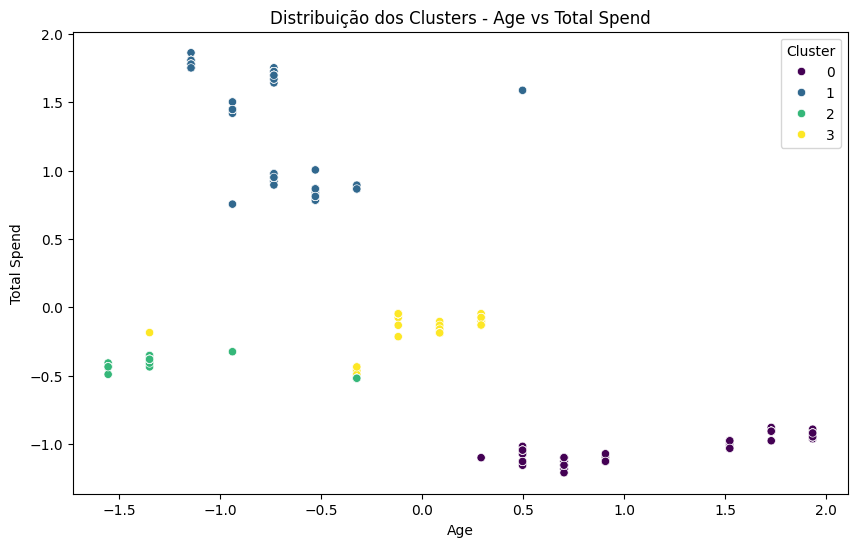

In [19]:
# Dispersão de Total Spend vs Age, colorido por cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dados, x='Age', y='Total Spend', hue='Cluster', palette='viridis')
plt.title('Distribuição dos Clusters - Age vs Total Spend')
plt.show()


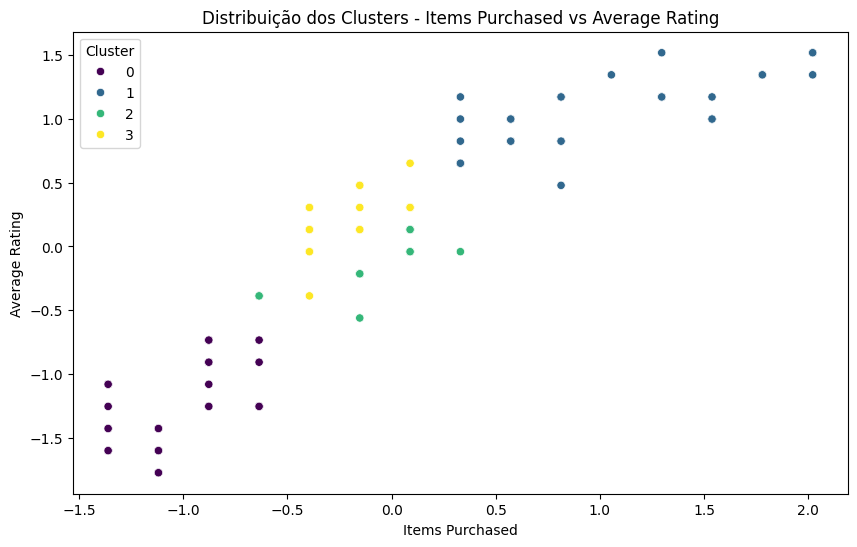

In [20]:
# Dispersão de Items Purchased vs Average Rating, colorido por cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=dados, x='Items Purchased', y='Average Rating', hue='Cluster', palette='viridis')
plt.title('Distribuição dos Clusters - Items Purchased vs Average Rating')
plt.show()

### 6.1 Visualizando e analizando o "Total Spend"

<Axes: xlabel='Total Spend'>

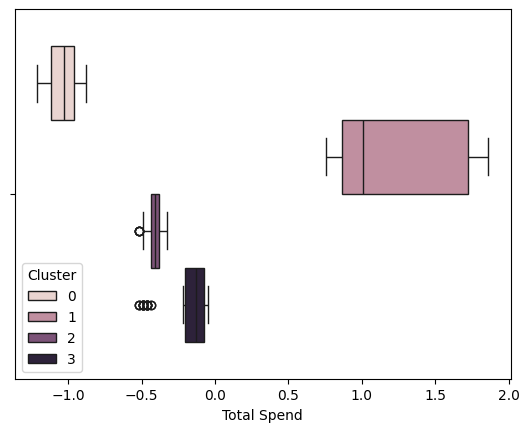

In [21]:
sns.boxplot(data=dados, x='Total Spend', hue='Cluster')

* cluster 0 -> Gasta menos que a media.
* cluster 1 -> O cluster com maior gasto.
* cluster 2 -> CLietes com gastos ligeiramente menos que a media. E possui agum valor muito abaixo, um outlier
* cluster 3 -> CLientes com um comportamento mais variavel que os de mais, sendo uma combinacao de valores baixos e medios, mas sem gastos altos.

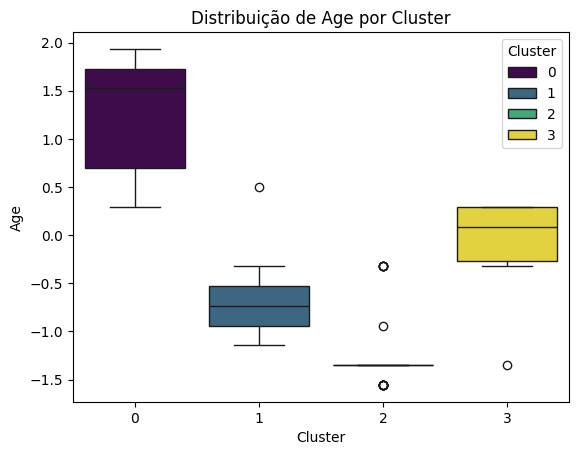

In [22]:
sns.boxplot(data=dados, x='Cluster', y='Age', palette='viridis', hue='Cluster')
plt.title('Distribuição de Age por Cluster')
plt.show()


* cluster 0 -> Clientes com as maiores idades.
* cluster 1 -> Clientes com idade ligeiramente menor que a media.
* cluster 2 -> Clientes com as menores idades entre os dados, e que apresenta mais outliers
* cluster 3 -> Clientes com as idades bem proximas da media global.

### 6.2 Distribuicao dos clusters

In [23]:
# 9. Scatter 2D dos Clusters via PCA
import plotly.express as px
from sklearn.decomposition import PCA
import pandas as pd

pca = PCA(n_components=2)
componentes = pca.fit_transform(dados[num_columns])

variancia_explicada = pca.explained_variance_ratio_

pca_df = pd.DataFrame({
    'PCA 1': componentes[:, 0],
    'PCA 2': componentes[:, 1],
    'Cluster': dados['Cluster'].astype(str),
    'Idade (norm)': dados['Age'].values,
    'Gasto Total (norm)': dados['Total Spend'].values,
    'Itens Comprados (norm)': dados['Items Purchased'].values,
})

fig = px.scatter(
    pca_df,
    x='PCA 1', y='PCA 2',
    color='Cluster',
    title='Distribuição dos Clusters em 2D via PCA',
    hover_data={
        'Idade (norm)': ':.2f',
        'Gasto Total (norm)': ':.2f',
        'Itens Comprados (norm)': ':.2f',
        'PCA 1': False,
        'PCA 2': False,
    },
    color_discrete_sequence=px.colors.qualitative.Vivid,
    opacity=0.80,
)

fig.update_traces(marker=dict(size=7))

fig.update_layout(
    title_font_size=18,
    xaxis_title=f'Componente Principal 1  ({variancia_explicada[0]*100:.1f}% da variância)',
    yaxis_title=f'Componente Principal 2  ({variancia_explicada[1]*100:.1f}% da variância)',
    xaxis=dict(showgrid=True, gridcolor='#E5E5E5', zeroline=True, zerolinecolor='#CCCCCC'),
    yaxis=dict(showgrid=True, gridcolor='#E5E5E5', zeroline=True, zerolinecolor='#CCCCCC'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend_title_text='Cluster',
    hovermode='closest'
)
fig.show()

print(f"\nVariância total explicada pelos 2 componentes: {sum(variancia_explicada)*100:.1f}%")


Variância total explicada pelos 2 componentes: 91.4%


clusters relativamente bem separados e sem sobreposicao visual significativa, o que indica que os clientes dentro de cada cluster tem caracteristicas semelhantes. PAra determinar o quao bem seperados e o quao sobrepostos alguns pontos estao, sera usado o silhouette score

## 7. Silhouette Scorre

Para referencia:

* 0,7 a 1,0	Clusters fortemente definidos; alta separação entre grupos.
*  0,5 a 0,7	Boa separação entre clusters; clusters estão razoavelmente definidos.
* 0,25 a 0,5	Clusterização moderada; alguns grupos podem estar sobrepostos.
* 0,0 a 0,25	Clusters fracos; a separação entre clusters é baixa.
* Negativo (< 0)	Clusters mal formados; pontos podem estar no cluster errado.

In [24]:
silhouette = silhouette_score(dados[num_columns], dados['Cluster'])
print(f'O silhouette Score: {silhouette:.2f}')


O silhouette Score: 0.55


Valor 0.55 indica uma segmentao moderada a boa porem com espaco para melhorar. Temos uma boa separacao, mas ainda existe sobreposicao.

## 8. Analisando grafico do Silhouette Score

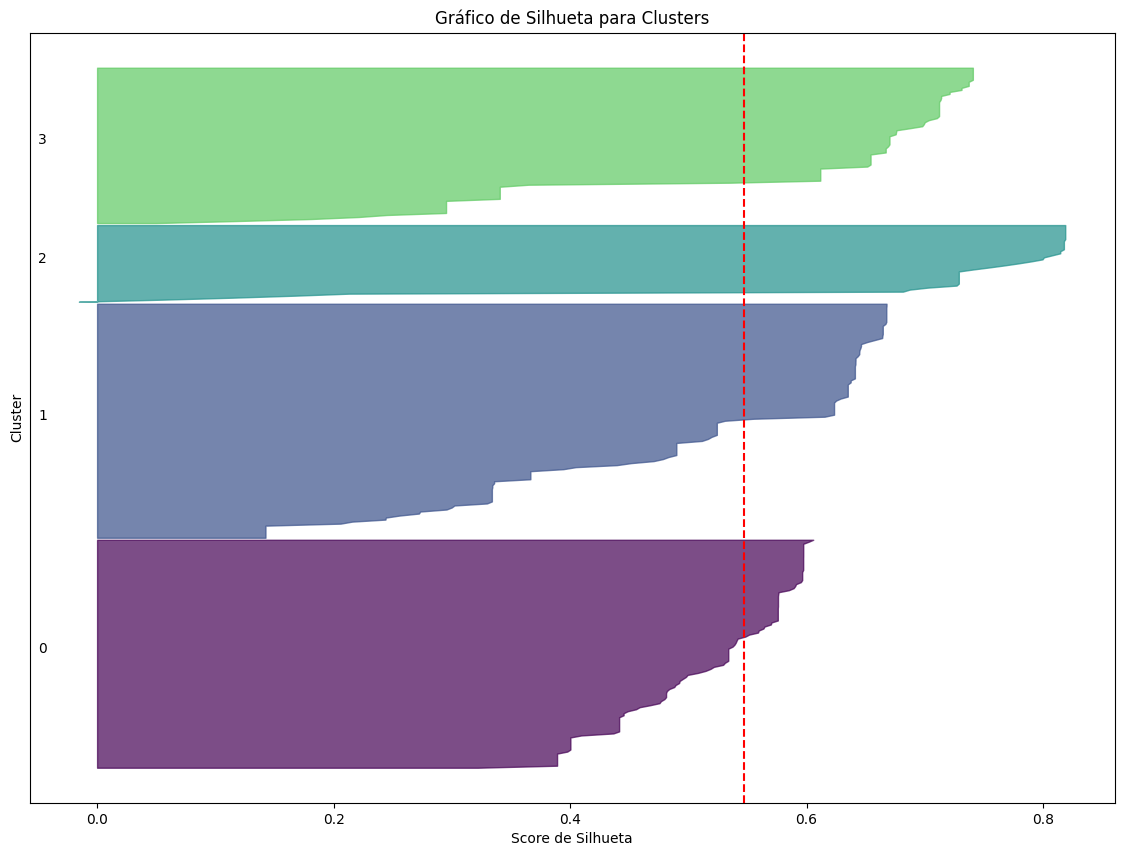

In [25]:
# Calcula os scores de silhueta para cada ponto
silhouette_vals = silhouette_samples(dados[num_columns], dados['Cluster'])

# Configurações do gráfico de silhueta
fig, ax = plt.subplots(figsize=(14, 10))
y_lower, y_upper = 0, 0
for i in range(4):  # Ajuste o range caso tenha escolhido outro valor de K
    cluster_silhouette_vals = silhouette_vals[dados['Cluster'] == i]
    cluster_silhouette_vals.sort()
    y_upper += len(cluster_silhouette_vals)
    color = plt.cm.viridis(float(i) / 4)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * len(cluster_silhouette_vals), str(i))
    y_lower = y_upper

ax.set_title("Gráfico de Silhueta para Clusters")
ax.set_xlabel("Score de Silhueta")
ax.set_ylabel("Cluster")
ax.axvline(x=silhouette_score(dados[num_columns], dados['Cluster']), color="red", linestyle="--")
ax.set_yticks([])
plt.show()


Distribuicao dos clusters:

Cluster 0: Com certa quantidade de pontos proximos a media, porem com alguns pontos bem abaixo, o que indica que estes pontos podem estar bem pretos de outros clusters indicando algum gau de sobreposicao.

CLuster 1: Distribuicao uniforme, com menos pontos abaixo da media que o cluster 0, o que indica que este esta bem separado.

Cluster 2: Cluster com a maior faixa de pontos, poucos pontos abaixo da media(porem pontos negativos), apesar um cluster bem definido e com baixa sobreposicao.

Cluster 3: Ampla distribuicao dos pontos, com a maioria acima da media o que indica um pontos bem alocados ao cluster, porem como alguns pontos permaneceram perto de 0 tem-se uma leve sobreposicao com outro clusters.

## 9. Melhoramento do Silhouette Score

Sera tentado:

1. Mudar o valor de k
2. Revisar as variaveis usadas
  * 2.2 Remocao ou adicao de variaveis


In [26]:
def create_kmeans(range_inicio:int, range_fim:int, dados=dados, num_columns=num_columns):
  for i in range(range_inicio, range_fim):
    kmeans = KMeans(n_clusters=i, random_state=42)
    dados['Cluster'] = kmeans.fit_predict(dados[num_columns])

    silhouette = silhouette_score(dados[num_columns], dados['Cluster'])
    print(f'O silhouette Score com {i} clusters: {silhouette:.4f}')


In [27]:
create_kmeans(2, 10)

/tmp/ipykernel_18234/465139534.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_18234/465139534.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_18234/465139534.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_1823

O silhouette Score com 2 clusters: 0.4820
O silhouette Score com 3 clusters: 0.4610
O silhouette Score com 4 clusters: 0.5468
O silhouette Score com 5 clusters: 0.5901
O silhouette Score com 6 clusters: 0.6561
O silhouette Score com 7 clusters: 0.6332
O silhouette Score com 8 clusters: 0.6683
O silhouette Score com 9 clusters: 0.6620


/tmp/ipykernel_18234/465139534.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_18234/465139534.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



A maxima atingiu com 8 clusters.

In [28]:
def grafico_silhouette(cluster:int):

  silhouette_vals = silhouette_samples(dados[num_columns], dados['Cluster'])

  fig, ax = plt.subplots(figsize=(10, 6))
  y_lower, y_upper = 0, 0
  for i in range(cluster):
      cluster_silhouette_vals = silhouette_vals[dados['Cluster'] == i]
      cluster_silhouette_vals.sort()
      y_upper += len(cluster_silhouette_vals)
      color = plt.cm.viridis(float(i) / cluster)
      ax.fill_betweenx(np.arange(y_lower, y_upper),
                      0, cluster_silhouette_vals,
                      facecolor=color, edgecolor=color, alpha=0.7)
      ax.text(-0.05, y_lower + 0.5 * len(cluster_silhouette_vals), str(i))
      y_lower = y_upper

  ax.set_title(f"Gráfico de Silhueta para {cluster} Clusters")
  ax.set_xlabel("Score de Silhueta:")
  ax.set_ylabel("Cluster")
  ax.axvline(x=silhouette_score(dados[num_columns], dados['Cluster']), color="red", linestyle="--")
  ax.set_yticks([])
  plt.show()

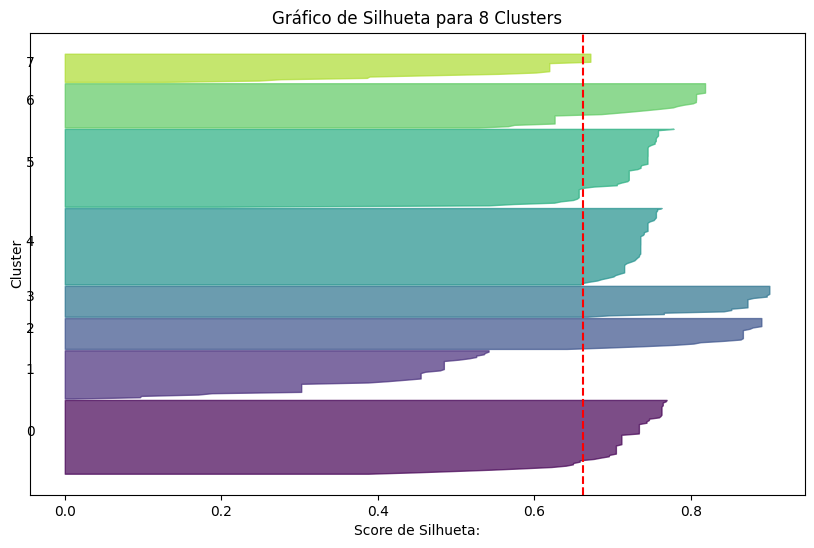

In [29]:
grafico_silhouette(8)

SObre o grafico:

Silhouette Score de 0.66 com 8 clusters, valor relativamente alto o indica que em sua maioria os valores estao bem separados dos outros clusters e compactos em seus clusters.

Pontos proximos de 0: Pouca quantidade, os quais indicam pouca sobreposicao entre clusters e que a maioria esta bem alocada em seus clusters.

CLiusters 0 e 6: possuem um distribuicao mais concentrada da media geral,
o que sugere clusters bem definidos e pontos bem agrupados.

Clusters 4 e 5: Tem uma variacao um pouco maior nos scores o que indica pontos proximos de outros clusters, mas sem deixar de estar razoavelmente bem definido.

Cluster 1: A maioria dos pontos esta bem agrupado, porem com um score abaixo da media geral, ele apresenta uma coesao ate aceitavel com uma qualidade inferior aos demais clusters. TAlvez pq suas caracteristicas sejam mais proximas a media e nao sejam exclusivas logo e um grupo menso diferenciado dos demais.

Cluster 7: com a maioria dos pontos em 0.6 e algums em 0.8 apresenta uma otima coesao e separacao. Trata-se de um lcusters compacto e bem separados indicando que possui caracteristicas bem especificas e distintas dos demais clusters.


porem mesmo alterando o numero de clusters o silhouette score ficou um tanto quanto perdo de 0.7, porem nao chegou ao valor, logo o proximo passo e usar as cariaveis categorias(nominais e orninais) para aumentar o valor do Score da silhoeta.

## 10. Analisando as variáveis categóricas para inclusão no modelo K-means

As variáveis que serão analisadas são:

* **Membership Type** e **Satisfaction Level** $\rightarrow$ Categóricas ordinais
* **Discount Applied** $\rightarrow$ Variável booleana
* **Gender** e **City** $\rightarrow$ Categóricas nominais

### 10.1 Normalização das variáveis numéricas

Fazendo o passo novamente para deixar em ordem e com lógica.

In [30]:
scaler = StandardScaler()

#num_columns = colunas numericas
dados[num_columns] = scaler.fit_transform(dados[num_columns])
dados.head(3)

/tmp/ipykernel_18234/3658166546.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Cluster
0,Female,-0.939761,New York,Gold,0.754230,0.330381,0.996757,True,-0.120022,Satisfied,1
1,Male,0.086720,Los Angeles,Silver,-0.186319,-0.394236,0.132172,False,-0.640260,Neutral,5
2,Female,1.934386,Chicago,Bronze,-0.933192,-0.877314,-1.078247,True,1.143413,Unsatisfied,4


### 10.2 Variável Ordinal: Membership Type

In [31]:
#qauntidade de valores a serem mapeados?
dados['Membership Type'].unique()
# 3 valores

array(['Gold', 'Silver', 'Bronze'], dtype=object)

In [32]:
member_map = {"Bronze": 1, "Silver": 2, "Gold": 3}
dados['Membership Type'] = dados['Membership Type'].map(member_map)
dados['Membership Type'].unique()


/tmp/ipykernel_18234/3129549368.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



array([3, 2, 1])

### 10.3 Variável Ordinal: Satisfaction Level

In [33]:
#Quantos niveis de satisfacao existem nos dados?
dados['Satisfaction Level'].unique()
# 3 niveis

array(['Satisfied', 'Neutral', 'Unsatisfied'], dtype=object)

In [34]:
member_map = {"Unsatisfied": 1, "Neutral": 2, "Satisfied": 3}
dados['Satisfaction Level'] = dados['Satisfaction Level'].map(member_map)
dados['Satisfaction Level'].unique()

/tmp/ipykernel_18234/953241372.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



array([3, 2, 1])

### 10.4 Variável Booleana: Discount Applied

In [35]:
#Como é boolena: True or false -> 1 or 0
dados['Discount Applied'] = dados['Discount Applied'].astype(int)
dados['Discount Applied'].unique()



/tmp/ipykernel_18234/682151156.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



array([1, 0])

### 10.5 Variáveis Nominais

Para as variáveis nominais (**Gender** e **City**), será realizado um *One-Hot Encoding*.

In [36]:
dados = pd.get_dummies(dados, columns=['Gender', 'City'], drop_first=True)

### 10.6 Normalização das novas variáveis numéricas

In [37]:
cat_columns = dados[['Membership Type', 'Satisfaction Level', 'Discount Applied']].columns
cat_columns

Index(['Membership Type', 'Satisfaction Level', 'Discount Applied'], dtype='object')

In [38]:
dados[cat_columns] = scaler.fit_transform(dados[cat_columns])
dados

,Age,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Cluster,Gender_Male,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco
0,-0.939761,1.216880,0.754230,0.330381,0.996757,0.994269,-0.120022,1.171147,1,False,False,False,False,True,False
1,0.086720,-0.010582,-0.186319,-0.394236,0.132172,-1.005764,-0.640260,-0.031092,5,True,False,True,False,False,False
2,1.934386,-1.238043,-0.933192,-0.877314,-1.078247,0.994269,1.143413,-1.233332,4,False,False,False,False,False,False
3,-0.734465,1.216880,1.751261,1.538076,1.169674,-1.005764,-1.086179,1.171147,8,True,False,False,False,False,True
4,-1.350354,-0.010582,-0.352721,0.088842,-0.040745,0.994269,2.109570,-1.233332,6,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
345,-0.323873,-0.010582,-0.519124,-0.635775,-0.386579,0.994269,1.143413,-1.233332,2,True,False,False,True,False,False
346,0.497312,-1.238043,-1.044635,-1.118853,-1.769915,-1.005764,0.028617,-0.031092,0,False,True,False,False,False,False
347,-0.734465,1.216880,0.949704,0.813459,0.823840,0.994269,0.102937,1.171147,1,False,False,False,False,True,False
348,0.086720,-0.010582,-0.187149,-0.394236,0.305089,-1.005764,-0.417301,-0.031092,5,True,False,True,False,False,False


nao e a melhor opcao usar o dataset todo para todos os passo. Aqui nao ouve problema pois se trata de 248 registros. Porem em um datasat maior seria necessario mais tempo para processar os passo usando todo o dataset, o melhor em tal caso seria usar parte por parte dos dados(Ex. separar as variaveis numericas das categoricas, processar e normalizar separado e depois juntar em um novo dataset normalizado.

In [39]:
print(f"Shape: {dados.shape}")
dados.head(3)

Shape: (348, 15)


,Age,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Cluster,Gender_Male,City_Houston,City_Los Angeles,City_Miami,City_New York,City_San Francisco
0,-0.939761,1.216880,0.754230,0.330381,0.996757,0.994269,-0.120022,1.171147,1,False,False,False,False,True,False
1,0.086720,-0.010582,-0.186319,-0.394236,0.132172,-1.005764,-0.640260,-0.031092,5,True,False,True,False,False,False
2,1.934386,-1.238043,-0.933192,-0.877314,-1.078247,0.994269,1.143413,-1.233332,4,False,False,False,False,False,False


## 11. K-means com todas as variáveis

O método do cotovelo determinará o valor de $K$.
Para isso, será feita uma comparação de 2 a 10 *clusters*.

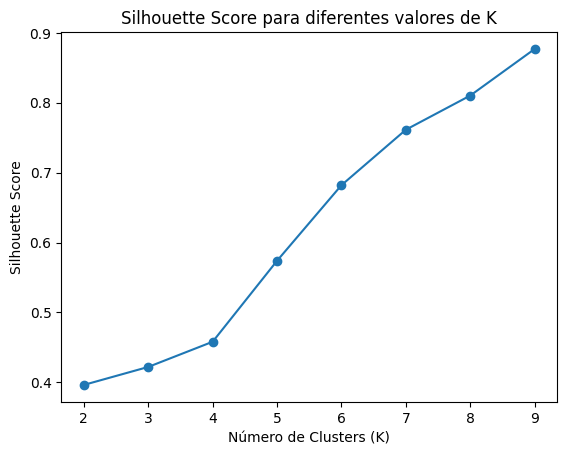

In [40]:
# Defina uma faixa de valores de K para testar
range_n_clusters = range(2, 10)
silhouette_scores = []

# Testa cada valor de K e calcula o Silhouette Score
for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    cluster_labels = kmeans.fit_predict(dados)
    silhouette_avg = silhouette_score(dados, cluster_labels)
    silhouette_scores.append(silhouette_avg)

# Exibe o gráfico de Silhouette Scores
plt.plot(range_n_clusters, silhouette_scores, marker='o')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score para diferentes valores de K')
plt.show()


Sera utilizado o primeiro valor de k que obteve um score maior que 0.7
E tambem testado o ultimo valor de k ande de obter um score de 0.7

In [41]:
dados['Cluster'].unique()

array([1, 5, 4, 8, 6, 0, 3, 2, 7], dtype=int32)

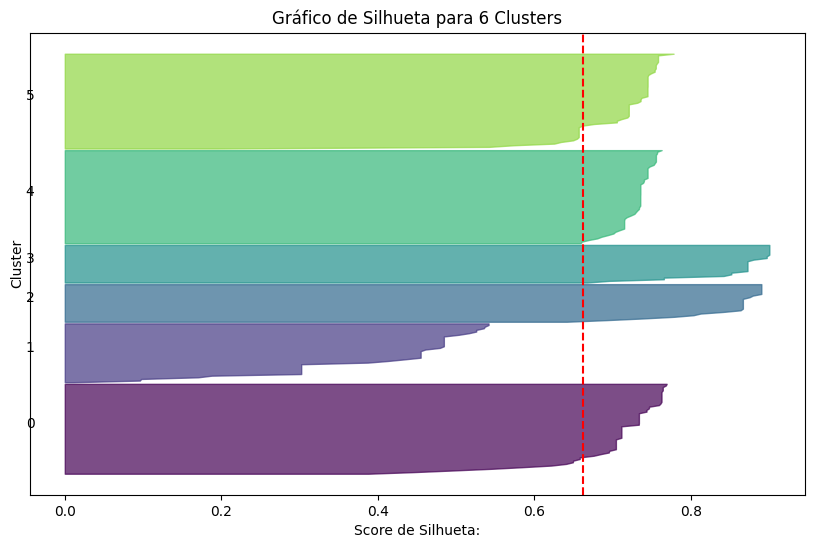

In [42]:
grafico_silhouette(6)


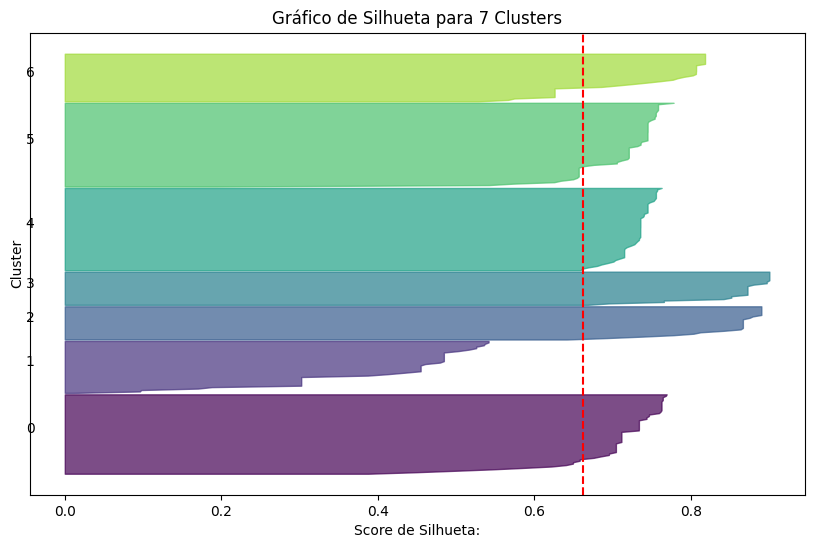

In [43]:
grafico_silhouette(7)


## 12. Analisando o K-means com 7 clusters

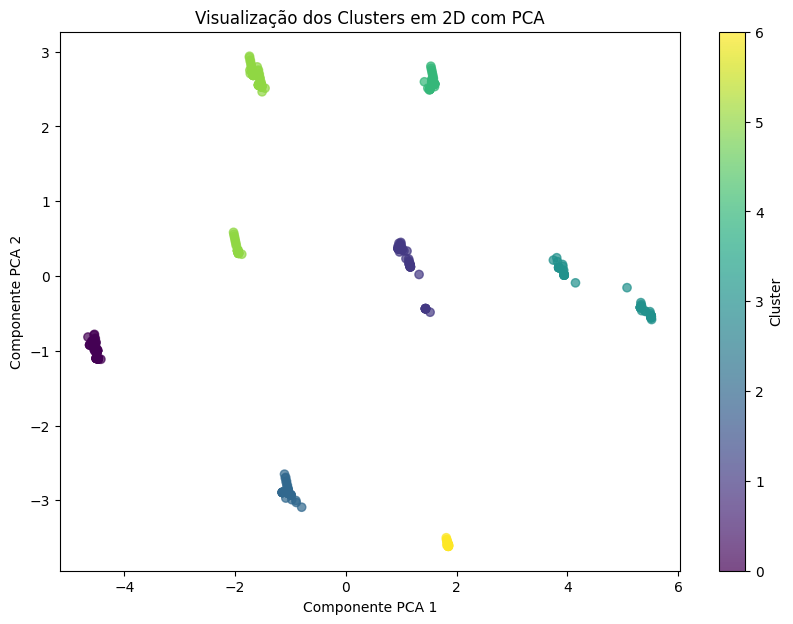

In [44]:
# Executa o KMeans com K = 7
kmeans = KMeans(n_clusters=7, random_state=42)
cluster_labels = kmeans.fit_predict(dados)

labels = kmeans.labels_ #Salvado as labels do kmeans escolhido, pode ser util para analises futuras

pca = PCA(n_components=2)
componentes_pca = pca.fit_transform(dados)

# Cria o scatter plot dos clusters em duas dimensões
plt.figure(figsize=(10, 7))
plt.scatter(componentes_pca[:, 0], componentes_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.colorbar(label='Cluster')
plt.xlabel('Componente PCA 1')
plt.ylabel('Componente PCA 2')
plt.title('Visualização dos Clusters em 2D com PCA')
plt.show()


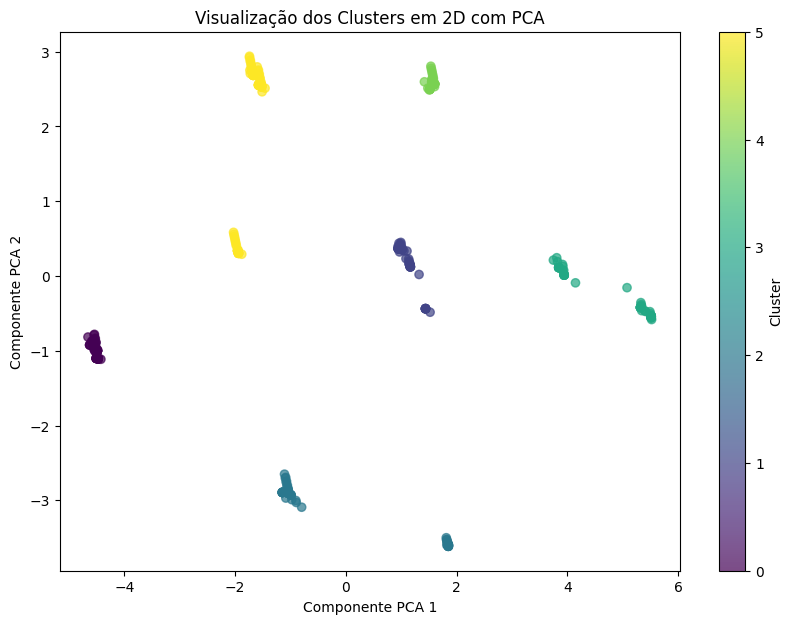

In [45]:
# Executa o KMeans com K = 6
kmeans = KMeans(n_clusters=6, random_state=42)
cluster_labels = kmeans.fit_predict(dados)

#PCA = 2
pca = PCA(n_components=2)
componentes_pca = pca.fit_transform(dados)


plt.figure(figsize=(10, 7))
plt.scatter(componentes_pca[:, 0], componentes_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.colorbar(label='Cluster')
plt.xlabel('Componente PCA 1')
plt.ylabel('Componente PCA 2')
plt.title('Visualização dos Clusters em 2D com PCA')
plt.show()

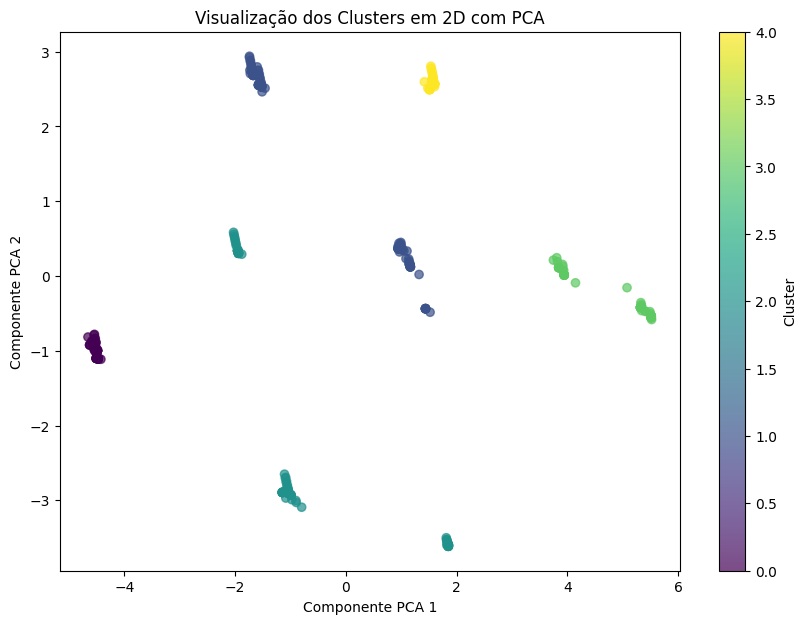

In [46]:
# Executa o KMeans com K = 5
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_labels = kmeans.fit_predict(dados)

#PCA = 2
pca = PCA(n_components=2)
componentes_pca = pca.fit_transform(dados)


plt.figure(figsize=(10, 7))
plt.scatter(componentes_pca[:, 0], componentes_pca[:, 1], c=cluster_labels, cmap='viridis', alpha=0.7)
plt.colorbar(label='Cluster')
plt.xlabel('Componente PCA 1')
plt.ylabel('Componente PCA 2')
plt.title('Visualização dos Clusters em 2D com PCA')
plt.show()

## 13. Analisando as características internas de cada cluster

In [47]:
dados_backup.dropna(inplace=True)
dados_backup.isna().sum()

,0
Gender,0
Age,0
City,0
Membership Type,0
Total Spend,0
Items Purchased,0
Average Rating,0
Discount Applied,0
Days Since Last Purchase,0
Satisfaction Level,0


In [48]:
dados_backup.head(3)

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level
0,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied
1,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral
2,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied


In [49]:
dados_backup['Cluster'] = labels

In [50]:
dados_reserva = dados_backup
dados_reserva.head(3)

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Cluster
0,Female,29,New York,Gold,1120.20,14,4.6,True,25,Satisfied,2
1,Male,34,Los Angeles,Silver,780.50,11,4.1,False,18,Neutral,1
2,Female,43,Chicago,Bronze,510.75,9,3.4,True,42,Unsatisfied,5


### 13.1 Distribuição das Variáveis Numéricas

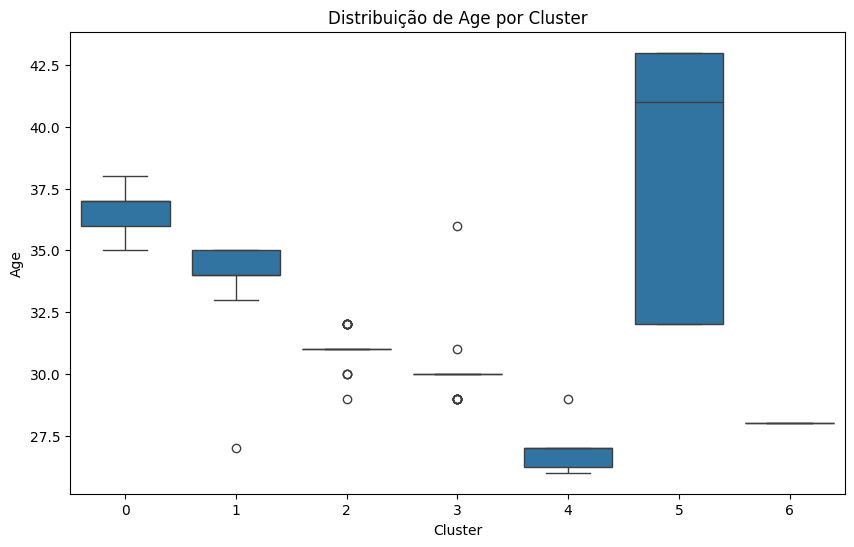

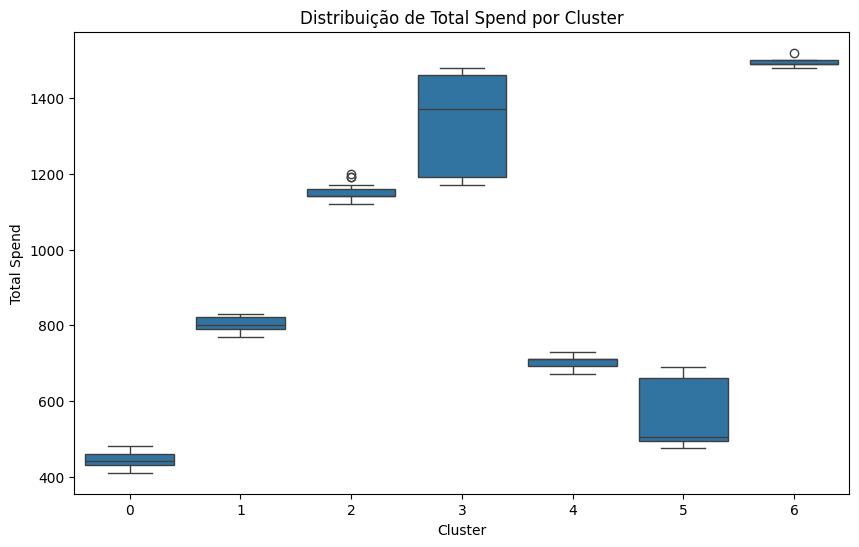

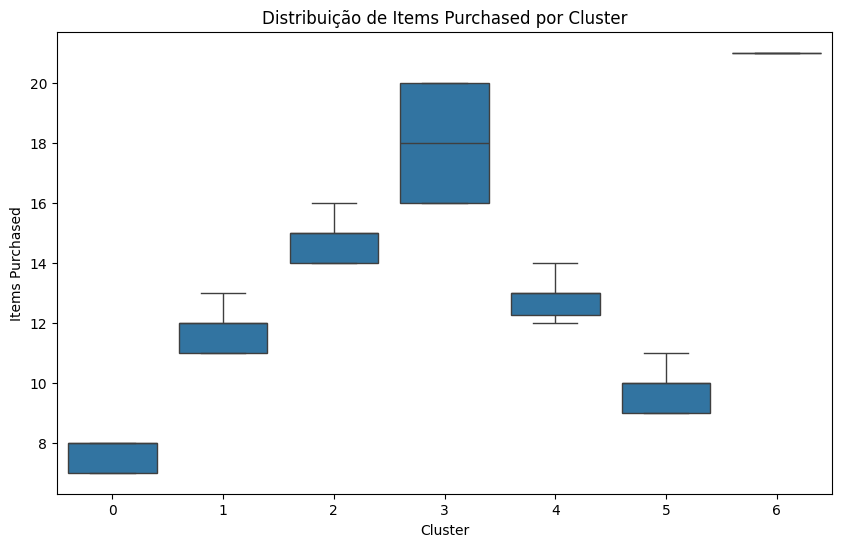

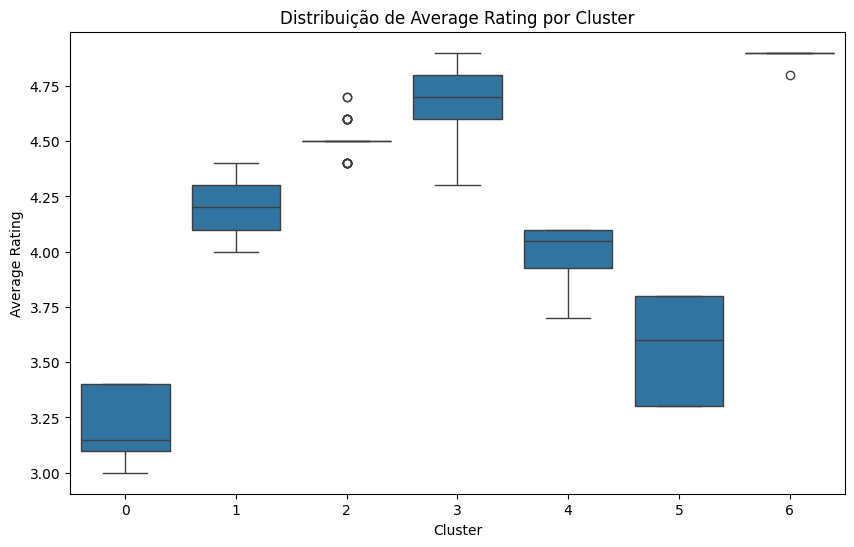

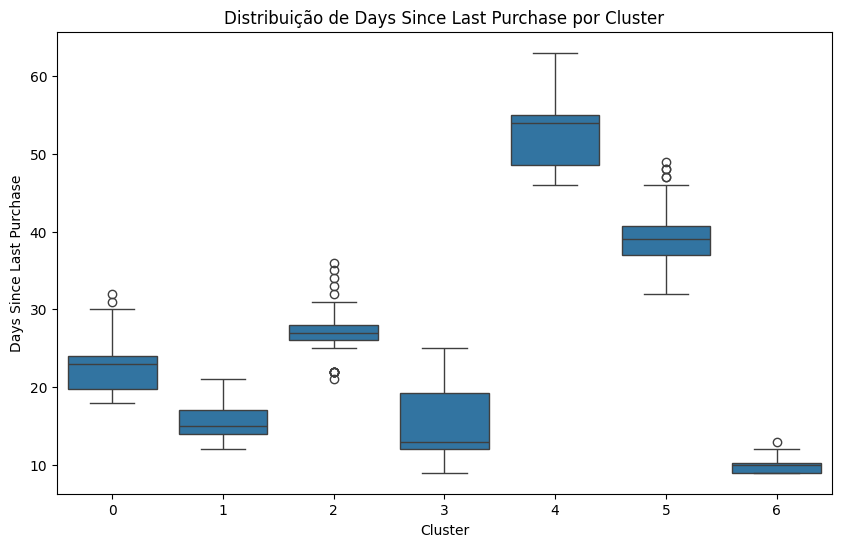

In [51]:
# Criando boxplots para cada variável numérica por cluster
for variavel in num_columns:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cluster', y=variavel, data=dados_backup)
    plt.title(f'Distribuição de {variavel} por Cluster')
    plt.show()


Age X Cluster:
* Os clusters 0,1 possuem idades relativamente altas, com pouca dispersao
* Os clusters 2, 3, 4 e 6 Possuem idades mais baixas e com pouca variacao
* O cluter 5, possui alta variacao de idade possuindo a maior faixa etaria

Total Spend
* O cluster 0 possui baixa variacao e os menores valores gastos.
* OS clusters 1, 4 possuem pouca variacao e um valor relativamente medio
* O cluster 2: POssui pouca variacao, e um valor relativamente alto
* O cluster 3: Possui a maior variacao, partindo de um gasta relativamente alto ate os maiores gastos, ficando apenas abaixo do cluster 6 neste quesito.
* O cluster 5: Possui uma varicao relativamente alta, com gastos entre os menores e medios. Maiores que o clusters 0 e menores que os clusters 1 e 4

Item Purchased
* AQui os clusters 0, 1, 3, 4, 5 possuem um varicao semelhante e o clusters 3 significativamente bem maior que os demais. Em relacao aos valores de quantidade, os cluster 0 tem a menor quantidade, os clusters 1 e 5 vem logo em seguida, apos os clusters 4 e 2 e por utlimo tambem com a maior quantidade vem o cluster 3.

Average Rating
* O cluster 0 tem a segunda maior variacao e a menor taxa de avaliacao
* OS clusters 1 e 3 possuem uma variacao muito semelhante porem com o 3 tendo uma taxa maior.
* O cluster 2 possui um pequenissima variacao e a 3ra maior taxa, e alguns consideraveis outliers
* O cluster 4 possui uma variao um pouco menor que os clusters 1 e 3, e valor de atxa menor que o 1ro.
* o CLuster 5 possui a  maior variacao de mavelor e a segunda menor taxa.
* O cluster 6 possui uma pequenissima variacao e a maior taxa de avaliacao

Days Since Last Purchase
* OS clusters 0 e 1 possuem um variacao semelhantes, com o 1ro sendo levemente menor que o 0 e com compras mais recorrentes.
* O cluster 3 possui uma recorrencia ainda menor que o cluster 0, porem com uma variacao relativamente menor  que os lcusters 0 e 1.
* O cluster 3 possui a maior variacao e a segunda maior recorrencia entre os clusters.
* O cluster 4 possui a segunda maior variacao e a menor recorrencia entre os clusters.
* O cluster 5 possui um varicao entre os clusters 0 e 1, porem com a segunda menor recorrencia.
* Por ultimo o cluster6 tem a manor variacao e a maior recorrencia de compras.



### 13.2 Distribuição das Variáveis Categóricas

In [52]:
cat_columns = dados[['Membership Type', 'Satisfaction Level', 'Discount Applied']].columns
cat_columns

Index(['Membership Type', 'Satisfaction Level', 'Discount Applied'], dtype='object')

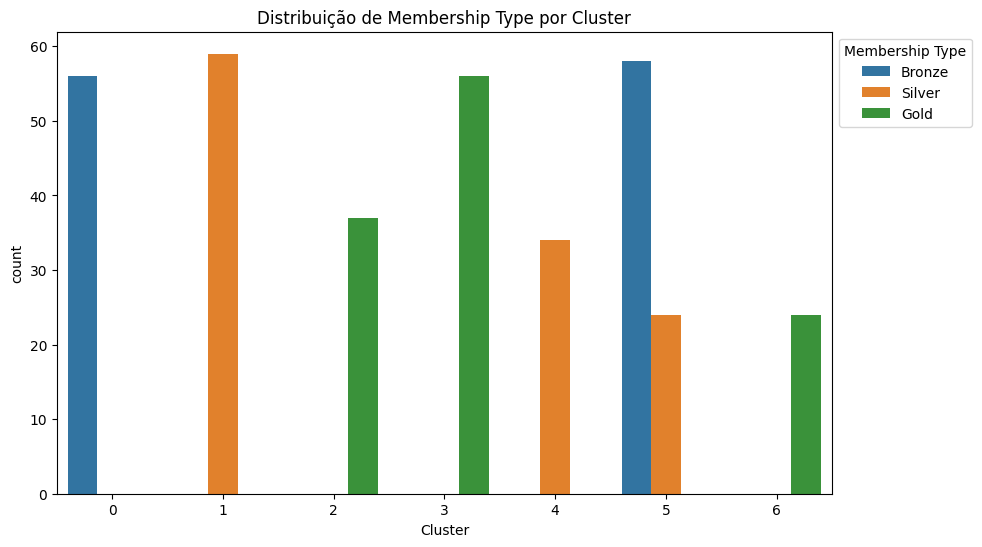

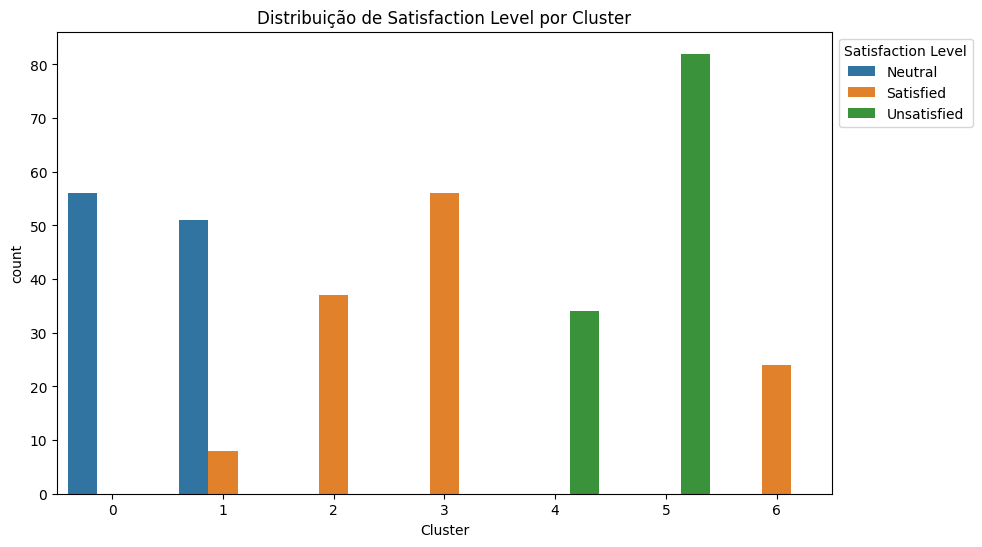

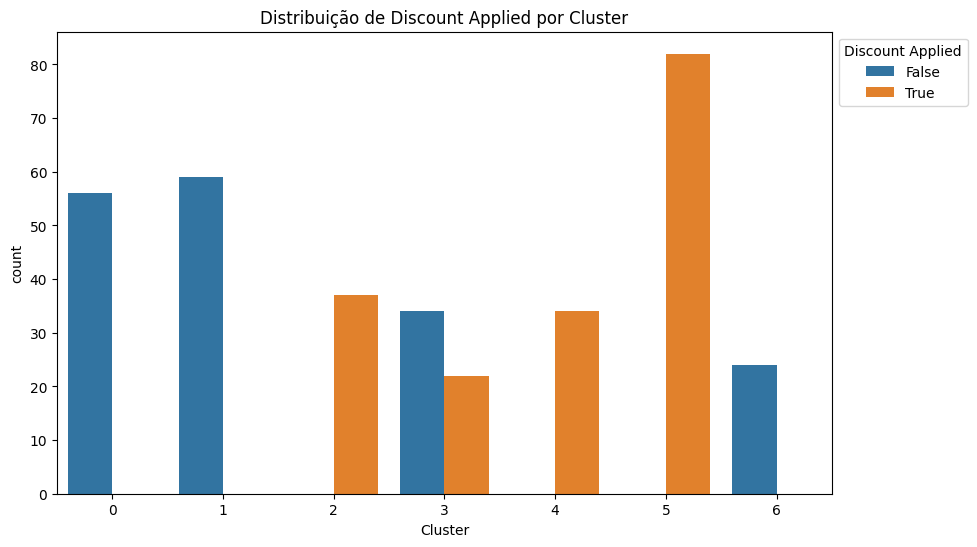

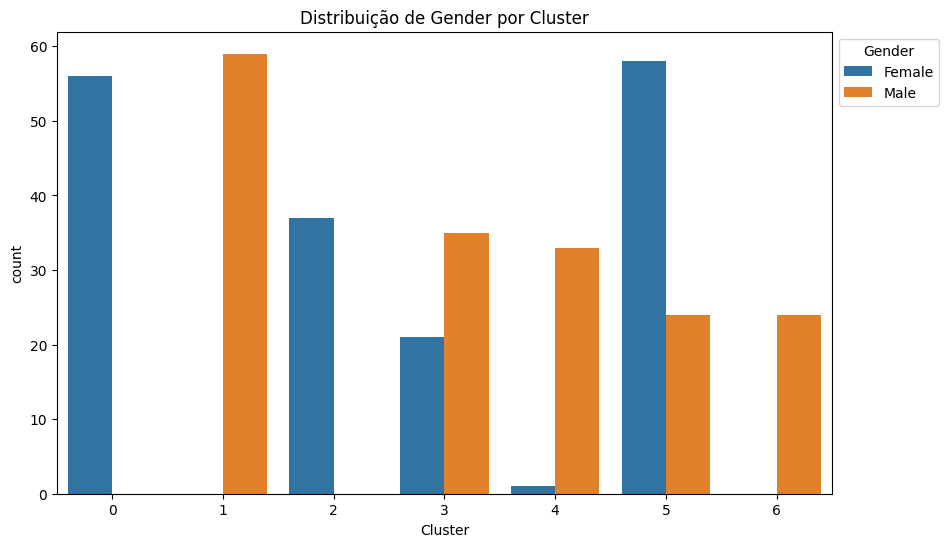

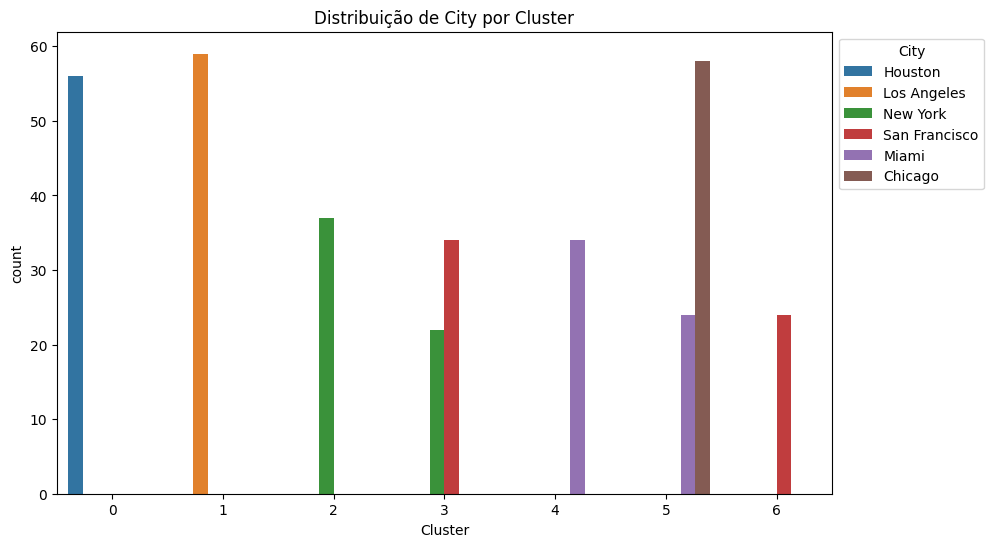

In [53]:
# Variáveis categóricas no dataset
variaveis_categoricas = ['Membership Type', 'Satisfaction Level', 'Discount Applied','Gender', 'City' ]  # Substitua pelos nomes reais das variáveis categóricas

# Gráficos de barras para variáveis categóricas
for variavel in variaveis_categoricas:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='Cluster', hue=variavel, data=dados_backup)
    plt.title(f'Distribuição de {variavel} por Cluster')
    plt.legend(title=variavel, bbox_to_anchor=(1, 1),loc='upper left')
    plt.show()


Membership Type

* Apenas o cluster 5 nao e de totalidade
* Sendo os clusters 0, 1, 3 de tamanhos proximos e mais 55.
* Ja os clusters 2, 4 se assemelham em >35 < 40.
* E o cluster 6 apreseta menor quantidade < 30.


Satisfaction Level
* Apenas o cluster 1 apresenta mais de um tipo de satisfacao
* Os dois clusters que apresentam 'Unsatisfied" apresentam em totalidade
* Ja "NEutral" e "Satisfied" apresentam clusters isolados e um compartilhado

Discount
* O cluster 5 teve disconto aplicado e tambem e maior total
* Os clusters 0 e 1 Apresetaram valores altos sem discontos
* os clusters 2, 4, apresentaram tiverem apenas descontos e com numero menor que os cluster 0 e 1
* o Cluster 6 possui a menor quantidade e sem desconto
* O cluster 3 e o unico nao totalizado de um lado

Gender
* OS clusters 0, 1, 2 e 6 sao totalitarios sendo eles F M F M
* OS clusters 3, 4, 5 sao dividos, semndo em maioria M M F

City
* Cluster 0 E totalidade de Houston.
* Cluster 1 E totalidade de Los Angeles.
* Cluster 2 E totalidade de New York.
* Cluster 3 - Maioriade de San Francisco, e um poco de New York.
* Cluster 4 E totalidade de Miami.
* Cluster 5 - A maioria dos clientes é de Chicago, e uma porcao de Miami.
* Cluster 6 E totalidade de San Francisco.

In [54]:
# Sunburst — Composição Categórica dos Clusters (sugestão gemini)
variaveis_sunburst = ['Membership Type', 'Satisfaction Level', 'Gender']

for variavel in variaveis_sunburst:
    sunburst_df = (
        dados_backup
        .groupby(['Cluster', variavel])
        .size()
        .reset_index(name='Contagem')
    )
    sunburst_df['Cluster'] = 'Cluster ' + sunburst_df['Cluster'].astype(str)

    fig = px.sunburst(
        sunburst_df,
        path=['Cluster', variavel],
        values='Contagem',
        title=f'Composição dos Clusters por {variavel}',
        color='Cluster',
        color_discrete_sequence=px.colors.qualitative.Vivid,
    )
    fig.update_layout(
        title_font_size=18,
        paper_bgcolor='white',
        margin=dict(t=60, l=10, r=10, b=10)
    )
    fig.update_traces(
        textinfo='label+percent entry',
        insidetextorientation='radial'
    )
    fig.show()

## 14. Características de média e mediana por cluster

### 14.1 Variáveis Numéricas

In [55]:
num_columns

Index(['Age', 'Total Spend', 'Items Purchased', 'Average Rating',
       'Days Since Last Purchase'],
      dtype='object')

In [56]:
num_cluster = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating',
       'Days Since Last Purchase', 'Cluster']

### 14.1.1 Média

In [57]:
dados_backup[num_cluster].groupby('Cluster').mean()

,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
Cluster,,,,,
0,36.696429,447.648214,7.589286,3.191071,22.785714
1,34.118644,805.491525,11.677966,4.172881,15.271186
2,31.108108,1150.532432,14.810811,4.508108,27.000000
3,29.964286,1339.675000,18.017857,4.691071,15.321429
4,26.794118,703.688235,12.764706,4.017647,53.176471
5,39.085366,550.126829,9.597561,3.557317,38.756098
6,28.000000,1492.183333,21.000000,4.895833,10.083333


### 14.1.2 Mediana

In [58]:
dados_backup[num_cluster].groupby('Cluster').median()


,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase
Cluster,,,,,
0,37.0,440.90,8.0,3.15,23.0
1,34.0,800.90,12.0,4.20,15.0
2,31.0,1140.60,15.0,4.50,27.0
3,30.0,1370.20,18.0,4.70,13.0
4,27.0,710.40,13.0,4.05,54.0
5,41.0,505.75,10.0,3.60,39.0
6,28.0,1490.10,21.0,4.90,10.0


### 14.2 Variáveis Categóricas Codificadas

In [59]:
dados_backup_codificado = dados_backup
member_map = {"Bronze": 1, "Silver": 2, "Gold": 3}
dados_backup_codificado['Membership Type'] = dados_backup_codificado['Membership Type'].map(member_map)

level_map = {"Unsatisfied": 1, "Neutral": 2, "Satisfied": 3}
dados_backup_codificado['Satisfaction Level'] = dados_backup_codificado['Satisfaction Level'].map(level_map)


dados_backup_codificado['Discount Applied'] = dados_backup_codificado['Discount Applied'].astype(int)

gender_map = {"Male": 1, "Female": 2}
dados_backup_codificado['Gender'] = dados_backup_codificado['Gender'].map(gender_map)

city_map = {"New York": 1, "Los Angeles": 2, "Chicago":3, "San Francisco":4, "Miami":5, "Houston":6}
dados_backup_codificado['City'] = dados_backup_codificado['City'].map(city_map)

dados_backup_codificado.head(3)

,Gender,Age,City,Membership Type,Total Spend,Items Purchased,Average Rating,Discount Applied,Days Since Last Purchase,Satisfaction Level,Cluster
0,2,29,1,3,1120.20,14,4.6,1,25,3,2
1,1,34,2,2,780.50,11,4.1,0,18,2,1
2,2,43,3,1,510.75,9,3.4,1,42,1,5


In [60]:
variavies_cat_cod = ['Membership Type', 'Satisfaction Level', 'Discount Applied', 'Gender', 'City', 'Cluster']
dados_backup_codificado[variavies_cat_cod].groupby('Cluster').mean()


,Membership Type,Satisfaction Level,Discount Applied,Gender,City
Cluster,,,,,
0,1.000000,2.000000,0.000000,2.000000,6.000000
1,2.000000,2.135593,0.000000,1.000000,2.000000
2,3.000000,3.000000,1.000000,2.000000,1.000000
3,3.000000,3.000000,0.392857,1.375000,2.821429
4,2.000000,1.000000,1.000000,1.029412,5.000000
5,1.292683,1.000000,1.000000,1.707317,3.585366
6,3.000000,3.000000,0.000000,1.000000,4.000000


Evidentemente que analisar as medias de variaveis categoricas codificadas nao eh a melhor maneira de fazer-lo. Porem eh possivel atraves da media identificar o padrao de dominacia que cada variavel tende a ter por clusters. A nao ser na categoria "City" Ai nao serve pra nada mesmo.
A categoria "City" sera feita abaixo de outrta forma.

Membership Type
* O Cluster 0: Possui media 1 que indica predominancia de clientes Bronze
* O Cluster 1: POssui media 2, ou seja predominacia de clientes Silver
* Cluster 2, 3, 6: COm media 3 -> Clientes Gold
* Cluster 5: O unico que nao possui um totalidade de tipo, com uma media 1,29 indica a maioria Bronze, com alguns clientes Silver

Satisfaction Level
* Cluster 1: COm um valor de 2,13, indicando que a maioria pertence a NEutral
* CLusters 2, 3, 6: Com media 3.0 idica a predominancia de clientes Satisfied
* Clusters 4, 5: Com media 1.0 aponta para clientes Unsatified

Discount Applied
* Clusters 0, 1, 6: Totais sem desconto
* Clusters 2, 5, 4: Totais com desconto
* Cluster 3: Parcial, com valor de 0.39 indica que a maioria nao aplicou desconto

GEnder
* CLusters 0 e 2: Sao de totalidade Female
* CLusters 1 e 6: SAo de totalidade Male
* Cluster 5: E parciail porem de maioridade Female
* Clusters 3 e  4: Sao parciais mas de ttalidade Male





In [61]:
dados_backup.groupby(['Cluster', 'City']).size().unstack()
dist_genero = dados_backup.groupby(['Cluster', 'City']).size().unstack()
dist_genero

City,1,2,3,4,5,6
Cluster,,,,,,
0,NaN,NaN,NaN,NaN,NaN,56.0
1,NaN,59.0,NaN,NaN,NaN,NaN
2,37.0,NaN,NaN,NaN,NaN,NaN
3,22.0,NaN,NaN,34.0,NaN,NaN
4,NaN,NaN,NaN,NaN,34.0,NaN
5,NaN,NaN,58.0,NaN,24.0,NaN
6,NaN,NaN,NaN,24.0,NaN,NaN


## 15. Avaliando a importância das variáveis

Após analisar o comportamento de todas as variáveis em relação aos clusters, é hora de verificar a importância delas para o modelo.

### 15.1 Teste ANOVA

Para variáveis numéricas

In [62]:
variaveis_numericas = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating',
       'Days Since Last Purchase']
variaveis_numericas

['Age',
 'Total Spend',
 'Items Purchased',
 'Average Rating',
 'Days Since Last Purchase']

In [63]:
resultados = {}
for variavel in variaveis_numericas:
    grupos = [dados_backup[dados_backup['Cluster'] == cluster][variavel] for cluster in dados_backup['Cluster'].unique()]
    f_valor, p_valor = f_oneway(*grupos)
    resultados[variavel] = p_valor

anova_df = pd.DataFrame(resultados.items(), columns=['Variável', 'P-valor'])
print("Resultados do teste ANOVA para variáveis numéricas:")
print(anova_df)

Resultados do teste ANOVA para variáveis numéricas:
                   Variável        P-valor
0                       Age  4.693463e-104
1               Total Spend  7.920047e-252
2           Items Purchased  3.281110e-231
3            Average Rating  7.608132e-210
4  Days Since Last Purchase  4.000928e-187


Valor de p < 0.05 serao usados. E neste caso todos sao

### 15.2 Teste Qui-Quadrado

Para variáveis categóricas

In [64]:
variaveis_categoricas = ['Membership Type', 'Gender', 'Satisfaction Level', 'Discount Applied', 'City']


In [65]:
chi2_results = {}
for variavel in variaveis_categoricas:
    tabela_contingencia = pd.crosstab(dados_backup['Cluster'], dados_backup[variavel])
    chi2, p_valor, _, _ = chi2_contingency(tabela_contingencia)
    chi2_results[variavel] = p_valor

chi2_results_df = pd.DataFrame(chi2_results.items(), columns=['Variável', 'P-valor'])
print("Resultados do teste Qui-quadrado para variáveis categóricas:")
print(chi2_results_df)


Resultados do teste Qui-quadrado para variáveis categóricas:
             Variável        P-valor
0     Membership Type  2.360842e-119
1              Gender   1.681904e-45
2  Satisfaction Level  2.697331e-132
3    Discount Applied   1.191773e-60
4                City  5.124913e-271


O teste Qui-Quadrado apresentou tambem todos os valores < 0.05

logo todas as variaveis serao usadas e nos teremos sete perfis de clientes

## 16. Montando Perfis de Clientes

Serão 7 perfis, um para cada *cluster*.

In [66]:
clusters_info = {
    0: {"Age": 36.7, "Total Spend": 447.65, "Items Purchased": 7.59, "Average Rating": 3.19, "Days Since Last Purchase": 22.8, "Membership Type": "Basic", "Gender": "Female", "City": "Houston"},
    1: {"Age": 34.1, "Total Spend": 805.49, "Items Purchased": 11.68, "Average Rating": 4.17, "Days Since Last Purchase": 15.27, "Membership Type": "Silver", "Gender": "Male", "City": "Los Angeles"},
    2: {"Age": 31.1, "Total Spend": 1150.53, "Items Purchased": 14.81, "Average Rating": 4.51, "Days Since Last Purchase": 27, "Membership Type": "Gold", "Gender": "Female", "City": "New York"},
    3: {"Age": 29.96, "Total Spend": 1339.68, "Items Purchased": 18.02, "Average Rating": 4.69, "Days Since Last Purchase": 15.32, "Membership Type": "Gold", "Gender": "Mixed", "City": "New York / San Francisco"},
    4: {"Age": 26.8, "Total Spend": 703.69, "Items Purchased": 12.76, "Average Rating": 4.01, "Days Since Last Purchase": 53.18, "Membership Type": "Silver", "Gender": "Male", "City": "Miami"},
    5: {"Age": 39.08, "Total Spend": 550.13, "Items Purchased": 9.6, "Average Rating": 3.56, "Days Since Last Purchase": 38.76, "Membership Type": "Basic-Silver", "Gender": "Mixed", "City": "Chicago / Miami"},
    6: {"Age": 28.0, "Total Spend": 1492.18, "Items Purchased": 21.0, "Average Rating": 4.9, "Days Since Last Purchase": 10, "Membership Type": "Gold", "Gender": "Male", "City": "San Francisco"},
    "Mean": { "Age":	32.2, "Total Spend": 927.05, "Items Purchased": 13.63, "Average Rating": 4.14, "Days Since Last Purchase": 26.04}
}
                                                                                                                    #{"New York": 1, "Los Angeles": 2, "Chicago":3, "San Francisco":4, "Miami":5, "Houston":6}
clusters_df = pd.DataFrame.from_dict(clusters_info, orient='index')
clusters_df



,Age,Total Spend,Items Purchased,Average Rating,Days Since Last Purchase,Membership Type,Gender,City
0,36.70,447.65,7.59,3.19,22.80,Basic,Female,Houston
1,34.10,805.49,11.68,4.17,15.27,Silver,Male,Los Angeles
2,31.10,1150.53,14.81,4.51,27.00,Gold,Female,New York
3,29.96,1339.68,18.02,4.69,15.32,Gold,Mixed,New York / San Francisco
4,26.80,703.69,12.76,4.01,53.18,Silver,Male,Miami
5,39.08,550.13,9.60,3.56,38.76,Basic-Silver,Mixed,Chicago / Miami
6,28.00,1492.18,21.00,4.90,10.00,Gold,Male,San Francisco
Mean,32.20,927.05,13.63,4.14,26.04,NaN,NaN,NaN


In [67]:
# 10. Radar spider dos Perfis dos Clusters
import plotly.graph_objects as go
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Variáveis numéricas originais
features_radar = ['Age', 'Total Spend', 'Items Purchased', 'Average Rating', 'Days Since Last Purchase']

# Média de cada feature por cluster (dados originais não normalizados)
radar_df = dados_backup.groupby('Cluster')[features_radar].mean()

# Normaliza entre 0 e 1 para comparação visual justa entre features
scaler_radar = MinMaxScaler()
radar_normalizado = pd.DataFrame(
    scaler_radar.fit_transform(radar_df),
    index=radar_df.index,
    columns=features_radar
)

# Labels mais legíveis para o gráfico
labels_radar = ['Idade', 'Gasto Total', 'Itens Comprados', 'Avaliação Média', 'Dias s/ Compra']

cores = px.colors.qualitative.Vivid

fig = go.Figure()

for i, cluster in enumerate(radar_normalizado.index):
    valores = radar_normalizado.loc[cluster].tolist()
    valores += valores[:1]  # fecha o polígono

    fig.add_trace(go.Scatterpolar(
        r=valores,
        theta=labels_radar + [labels_radar[0]],
        fill='toself',
        fillcolor=cores[i % len(cores)],
        opacity=0.15,
        line=dict(color=cores[i % len(cores)], width=2.5),
        name=f'Cluster {cluster}'
    ))

fig.update_layout(
    title=dict(
        text='Perfil Médio dos Clusters — Variáveis Normalizadas',
        font_size=18
    ),
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],
            tickvals=[0.25, 0.50, 0.75, 1.0],
            ticktext=['25%', '50%', '75%', '100%'],
            tickfont=dict(size=10),
            gridcolor='#DDDDDD',
        ),
        angularaxis=dict(
            tickfont=dict(size=13),
            gridcolor='#DDDDDD',
        ),
        bgcolor='white'
    ),
    paper_bgcolor='white',
    legend=dict(
        title='Cluster',
        orientation='v',
        x=1.15
    ),
    showlegend=True
)
fig.show()

Perfil cluster 0:
Idade mais avancada que a media, gasta menos que a media(Tem o menor gasto alias), o que menos compra em quantidades e a menor satisfacao, ao menos tem uma recorrencia levemente melhor que a media.

Perfil cluster 1:
Tem idade, total gasto, Qntd de itens e avalhacao bem proximos a media, porem com uma recorrencia interessante(Menor que a media e neste caso e bom).
Perfil cluster 2:
Idade levemente menor que a media, com gasto elevado, quantidade alta de itens e otima satisfacao. Sao engajados.

Perfil cluster 3:
Idade um pouco menor que a media, gastam bastante, compram muitos itens, possume uma alta frequencia de compra e uma satisfacao elevada. Clientes engajados e leais

Perfil cluster 4:
OS mais jovens, clientes de gastos, qtnd, e satisfacao levementes inferiores a media, mas uma frequencia bem menor que a media

Perfil cluster 5:
Os mais velhos, perfil muito similar aos cliente do Cluster 0, porem com uma recorrencia mais fraca.

Perfil cluster 6:
Clientes jovem, com maior gasto e qtnd comprada e a melhor satisfacao, OS melhor clientes.

Ranking de Clientes
6 -> 3 -> 2 -> 1 -> 4 -> 5 -> 0

Criterios:

* 6: Mais alto, valor, frequencia e satisfacao
* 3: Alto valor, alta frequencia, e alta satisfacao
* 2: Alto valor e satisfacao, com frequencia a melhorar
* 1: Valor e  satisfacao medios, com otima recorrencia  
* 4: Cliente levemente abaixo da media, com uma recorrencia fraca
* 5: Cliente levemente inferior ao 4, apenas com uma recorrencia um pouco melhor
* 0: Cliente do mais baixo gasto e satisfacao, com uma frequencia levemente menor que a media.

Estes perfil servem para a criacao de campanha exclusivas.

#### Cluster 0: Ocasional

Perfil: Clientes que compram esporadicamente, com baixo gasto médio e uma média de dias desde a última compra em torno de 22.

Campanha:
* Promoção de Retorno: Enviar um desconto exclusivo válido por um curto período para incentivar uma nova compra.

* Recuperação de Clientes Inativos: Lembretes de produtos que eles possam ter se interessado anteriormente, sugerindo itens complementares com uma oferta especial.

Objetivo: Aumentar a frequência de compras.

#### Cluster 1: Frequente de Médio Gasto

Perfil: Compra com regularidade e gasta um valor médio intermediário. Satisfação média e um número moderado de dias desde a última compra.

Campanha:
* Programa de Recompensas: Ofereça pontos de fidelidade ou um programa de cashback para compras futuras.
* Cross-Selling e Up-Selling: Sugerir produtos complementares de valor maior para aumentar o ticket médio.

Objetivo: Elevar o gasto médio por compra.

#### Cluster 2: Alto Gasto, Satisfeito e Fiel

Perfil: Alto gasto total, alta satisfação e frequência de compra.

Campanha:
* Acesso Antecipado e Exclusividades: Dar acesso antecipado a novos lançamentos ou itens limitados.
* Ofertas Personalizadas Premium: Criar ofertas premium que combinem com seu histórico de compras, como pacotes com produtos de alta qualidade.

Objetivo: Reforçar a fidelidade e manter a alta satisfação.

#### Cluster 3: Compradores Frequentes e Altamente Engajados

Perfil: Frequentemente compram e possuem um gasto médio alto, com uma avaliação média superior.

Campanha:
* Clube de Assinatura: Oferecer um modelo de assinatura ou plano de recompensas que aumente o engajamento.
* Evento VIP ou Webinar: Convidá-los para eventos exclusivos ou sessões ao vivo para lançamento de produtos.

Objetivo: Aumentar o lifetime value e a lealdade.

#### Cluster 4: Compradores Inconstantes
Perfil: Baixa frequência de compra, mas com histórico de gastos razoável. Possuem dias desde a última compra relativamente altos.

Campanha:
* E-mails de Reativação: Enviar e-mails com ofertas de produtos favoritos ou sugerir itens relacionados aos comprados anteriormente.
* Frete Grátis em Pedidos Acima de Certo Valor: Incentivar a volta com promoções para valores de compra que aumentem o ticket médio.

Objetivo: Aumentar a frequência e reter o cliente.

#### Cluster 5: Clientes Fiéis e Moderados
Perfil: Compras frequentes, mas com um gasto total menor comparado a outros clusters.

Campanha:
* Promoções de Volume: Ofereça descontos para compras em maior quantidade.
* Selo de Cliente VIP de Baixo Custo: Identificar esses clientes como “VIP de valor”, incentivando a fidelidade com brindes ou descontos para recompensas.

Objetivo: Estimular compras de maior volume ou ticket médio.

#### Cluster 6: Alto Gasto e Alta Frequência
Perfil: Clientes com o maior gasto e frequência. Alta avaliação média, e dias baixos desde a última compra.

Campanha:
* Experiência Exclusiva: Oferecer uma experiência exclusiva, como uma prévia de novos produtos ou um evento de agradecimento aos melhores clientes.
* Descontos Progressivos: Incentivar compras maiores com descontos que aumentam com o valor total do carrinho.

Objetivo: Manter a satisfação elevada e aumentar a lealdade.

In [68]:
import pkg_resources
dependencies = ['pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn']
for dep in dependencies:
    version = pkg_resources.get_distribution(dep).version
    print(f"{dep}=={version}")

/tmp/ipykernel_18234/2669526061.py:1: DeprecationWarning:

pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html



pandas==2.2.2
numpy==2.0.2
scikit-learn==1.6.1
matplotlib==3.10.0
seaborn==0.13.2
